# KAIROS — Validación con Datos Reales (Google Health)

## Objetivo

Este notebook demuestra que el pipeline de detección de KAIROS funciona correctamente
en datos reales no vistos, usando datos históricos de HR exportados de Google Health
del dispositivo Pixel Watch 3 de la autora.

**Pipeline replicado:**
1. Carga de datos reales de HR (Google Health Takeout)
2. Agrupación en ventanas de 60 segundos (igual que KAIROS)
3. Calibración del baseline personal con las primeras 3 ventanas en reposo
4. Cálculo de Z-scores (z_HR y z_RMSSD) contra el baseline personal
5. Inferencia con el modelo Random Forest (`kairos_model_final.pkl`)
6. Análisis de resultados y documentación de limitaciones

**Limitación documentada:** Google Health guarda la HR como valores enteros (BPM),
no como intervalos RR. El RMSSD calculado (~1.7ms) es artificialmente bajo comparado
con los 51ms de WESAD. Esta limitación es consistente con el comportamiento del
Pixel Watch 3 en la app KAIROS, donde tampoco se exponen los intervalos RR.

In [138]:
# ── Celda 1: Imports ──────────────────────────────────────────────────────────
import json
import glob
import csv
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import warnings
from datetime import datetime, time as dtime
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc, roc_auc_score
)
warnings.filterwarnings('ignore')

print('Imports OK ✅')

Imports OK ✅


In [139]:
# ── Celda 2: Cargar modelo ────────────────────────────────────────────────────
MODEL_PATH = '/home/alma/bot/kairos-mentor/kairos_app/dataset/kairos_model_final.pkl'
model = joblib.load(MODEL_PATH)

print(f'Modelo cargado ✅')
print(f'Tipo: {type(model).__name__}')
print(f'Features esperadas: {model.n_features_in_} → [z_hr, z_rmssd]')
print(f'Clases: {model.classes_} → 0=Calma, 1=Estrés')

Modelo cargado ✅
Tipo: RandomForestClassifier
Features esperadas: 2 → [z_hr, z_rmssd]
Clases: [0 1] → 0=Calma, 1=Estrés


In [375]:
# ── Celda 3: Definir fechas ───────────────────────────────────────────────────
FECHAS_ESTRES = pd.to_datetime([
'2026-01-23', '2026-02-09', '2026-03-02', '2026-06-09'
]).normalize()

FECHAS_CALMA = pd.to_datetime([
'2026-04-26', '2026-03-01', '2025-12-10', '2026-01-08'
]).normalize()

TODAS_FECHAS = list(FECHAS_ESTRES) + list(FECHAS_CALMA)

print('Fechas de estrés:')
for f in FECHAS_ESTRES: print(f'  {f.date()}')
print('Fechas de calma:')
for f in FECHAS_CALMA: print(f'  {f.date()}')

Fechas de estrés:
  2026-01-23
  2026-02-09
  2026-03-02
  2026-06-09
Fechas de calma:
  2026-04-26
  2026-03-01
  2025-12-10
  2026-01-08


In [376]:
# ── Celda 4: Cargar HR diurna desde JSON ─────────────────────────────────────
# Solo cargamos los archivos de los 8 días que necesitamos
# para evitar procesar los 225 archivos completos

HR_JSON_DIR = '/home/alma/bot/Takeout/Google Health/Global Export Data/'

samples = []
fechas_str = [f.strftime('%Y-%m-%d') for f in TODAS_FECHAS]

for fecha_str in fechas_str:
    path = f'{HR_JSON_DIR}heart_rate-{fecha_str}.json'
    try:
        with open(path) as fp:
            data = json.load(fp)
        for s in data:
            try:
                dt  = datetime.strptime(s['dateTime'], '%m/%d/%y %H:%M:%S')
                bpm = float(s['value']['bpm'])
                conf = int(s['value']['confidence'])
                if conf >= 2 and dtime(8,0) <= dt.time() <= dtime(22,0):
                    samples.append({'timestamp': dt, 'bpm': bpm})
            except:
                pass
        print(f'{fecha_str}: cargado ✅')
    except FileNotFoundError:
        print(f'{fecha_str}: archivo no encontrado ❌')

df_hr = pd.DataFrame(samples).sort_values('timestamp').reset_index(drop=True)
df_hr['fecha'] = df_hr['timestamp'].dt.normalize()

print(f'\nTotal muestras diurnas: {len(df_hr):,}')
print(f'HR media global: {df_hr["bpm"].mean():.1f} BPM')

2026-01-23: cargado ✅
2026-02-09: cargado ✅
2026-03-02: cargado ✅
2026-06-09: cargado ✅
2026-04-26: cargado ✅
2026-03-01: cargado ✅
2025-12-10: cargado ✅
2026-01-08: cargado ✅

Total muestras diurnas: 183,929
HR media global: 82.7 BPM


In [377]:
# ── Celda 5: Construir ventanas de 60s ───────────────────────────────────────
def procesar_dia(fecha, label, df_hr):
    dt = fecha.date()
    subset = df_hr[
        (df_hr['fecha'].dt.date == dt) &
        (df_hr['bpm'] <= 120)
    ].copy()

    if len(subset) < 10:
        print(f'  ⚠️  {dt}: pocas muestras ({len(subset)})')
        return pd.DataFrame()

    subset['window'] = subset['timestamp'].dt.floor('60s')

    ventanas = subset.groupby('window').agg(
        hr_mean  = ('bpm', 'mean'),
        hr_std_intra = ('bpm', 'std'),
        hr_count = ('bpm', 'count')
    ).reset_index()

    ventanas = ventanas[ventanas['hr_count'] >= 3]
    ventanas['hr_std_intra'] = ventanas['hr_std_intra'].fillna(0)
    ventanas['label'] = label
    ventanas['fecha'] = fecha
    return ventanas

filas = []
for fecha in FECHAS_ESTRES:
    filas.append(procesar_dia(fecha, 1, df_hr))
for fecha in FECHAS_CALMA:
    filas.append(procesar_dia(fecha, 0, df_hr))

df_ventanas = pd.concat([f for f in filas if not f.empty], ignore_index=True)

print(f'Total ventanas de 60s: {len(df_ventanas):,}')
print(f'  Calma (0):  {(df_ventanas["label"]==0).sum():,}')
print(f'  Estrés (1): {(df_ventanas["label"]==1).sum():,}')
print(f'\nHR media — Calma:  {df_ventanas[df_ventanas["label"]==0]["hr_mean"].mean():.1f} BPM')
print(f'HR media — Estrés: {df_ventanas[df_ventanas["label"]==1]["hr_mean"].mean():.1f} BPM')

Total ventanas de 60s: 6,277
  Calma (0):  3,244
  Estrés (1): 3,033

HR media — Calma:  75.2 BPM
HR media — Estrés: 87.8 BPM


In [378]:
# ── Celda 6: Filtro de movimiento con micro_motion ───────────────────────────
ZIP_PATH = '/home/alma/bot/takeout-20260612T142925Z-3-001.zip'
UMBRAL_MOVIMIENTO = 100

def cargar_motion(fecha, zip_path):
    fecha_str = fecha.strftime('%Y-%m-%d')
    path = f'Takeout/Google Health/Physical Activity_GoogleData/micro_motion_{fecha_str}.csv'
    try:
        with zipfile.ZipFile(zip_path) as zf:
            with zf.open(path) as f:
                df = pd.read_csv(f)
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_localize(None)
        df = df[df['timestamp'].dt.time.between(dtime(8,0), dtime(22,0))]
        df['magnitud'] = np.sqrt(df['mean x']**2 + df['mean y']**2 + df['mean z']**2)
        df['window']   = df['timestamp'].dt.floor('60s')
        df['fecha']    = fecha
        return df.groupby(['window','fecha'])['magnitud'].mean().reset_index()
    except Exception as e:
        print(f'  ⚠️  {fecha_str}: {e}')
        return pd.DataFrame()

motion_frames = []
for fecha in TODAS_FECHAS:
    df_m = cargar_motion(fecha, ZIP_PATH)
    if not df_m.empty:
        motion_frames.append(df_m)
        print(f'{fecha.date()}: {len(df_m)} ventanas de motion ✅')

df_motion = pd.concat(motion_frames, ignore_index=True)

# Merge con ventanas de HR
df_ventanas = df_ventanas.merge(df_motion[['window','magnitud']], on='window', how='left')
df_ventanas['magnitud'] = df_ventanas['magnitud'].fillna(df_ventanas['magnitud'].median())

# Aplicar filtro
df_filtrado = df_ventanas[df_ventanas['magnitud'] <= UMBRAL_MOVIMIENTO].copy()

print(f'\nVentanas antes del filtro:   {len(df_ventanas):,}')
print(f'Ventanas después del filtro: {len(df_filtrado):,}')
print(f'Descartadas por movimiento:  {len(df_ventanas)-len(df_filtrado):,}')
print(f'\nHR media — Calma:  {df_filtrado[df_filtrado["label"]==0]["hr_mean"].mean():.1f} BPM')
print(f'HR media — Estrés: {df_filtrado[df_filtrado["label"]==1]["hr_mean"].mean():.1f} BPM')

2026-01-23: 753 ventanas de motion ✅
2026-02-09: 769 ventanas de motion ✅
2026-03-02: 820 ventanas de motion ✅
2026-06-09: 775 ventanas de motion ✅
2026-04-26: 789 ventanas de motion ✅
2026-03-01: 841 ventanas de motion ✅
2026-01-08: 787 ventanas de motion ✅

Ventanas antes del filtro:   6,277
Ventanas después del filtro: 4,081
Descartadas por movimiento:  2,196

HR media — Calma:  78.7 BPM
HR media — Estrés: 94.4 BPM


In [379]:
# ── Celda 7: Calibración y Z-scores ──────────────────────────────────────────
baseline = df_filtrado[df_filtrado['label'] == 0]

HR_BL_MEAN  = baseline['hr_mean'].mean()
HR_BL_STD   = baseline['hr_mean'].std()
HRV_BL_MEAN = baseline['hr_std_intra'].mean()
HRV_BL_STD  = max(baseline['hr_std_intra'].std(), 0.1)

print('=== BASELINE PERSONAL (días de calma) ===')
print(f'HR basal:    {HR_BL_MEAN:.1f} BPM (±{HR_BL_STD:.1f})')
print(f'HRV basal:   {HRV_BL_MEAN:.2f} (±{HRV_BL_STD:.2f})')

# Z-scores
df_filtrado['z_hr']    = (df_filtrado['hr_mean'] - HR_BL_MEAN) / HR_BL_STD
df_filtrado['z_rmssd'] = (df_filtrado['hr_std_intra'] - HRV_BL_MEAN) / HRV_BL_STD

print(f'\nZ-scores — Calma:  z_hr: {df_filtrado[df_filtrado["label"]==0]["z_hr"].mean():.3f} | '
      f'z_rmssd: {df_filtrado[df_filtrado["label"]==0]["z_rmssd"].mean():.3f}')
print(f'Z-scores — Estrés: z_hr: {df_filtrado[df_filtrado["label"]==1]["z_hr"].mean():.3f} | '
      f'z_rmssd: {df_filtrado[df_filtrado["label"]==1]["z_rmssd"].mean():.3f}')
print(f'\n→ Ambos Z-scores deberían ser mayores en Estrés que en Calma')

=== BASELINE PERSONAL (días de calma) ===
HR basal:    78.7 BPM (±9.0)
HRV basal:   3.02 (±1.93)

Z-scores — Calma:  z_hr: -0.000 | z_rmssd: -0.000
Z-scores — Estrés: z_hr: 1.747 | z_rmssd: 0.391

→ Ambos Z-scores deberían ser mayores en Estrés que en Calma


In [380]:
# ── Celda 8: Inferencia ───────────────────────────────────────────────────────
X      = df_filtrado[['z_hr', 'z_rmssd']].values
y_true = df_filtrado['label'].values

df_filtrado['prob_crisis'] = model.predict_proba(X)[:, 1]
df_filtrado['pred_label']  = model.predict(X)

auc_score = roc_auc_score(y_true, df_filtrado['prob_crisis'])

print('=== INFERENCIA ===')
print(f'Ventanas analizadas: {len(df_filtrado):,}')
print(f'  Predicho Calma (0):  {(df_filtrado["pred_label"]==0).sum():,}')
print(f'  Predicho Estrés (1): {(df_filtrado["pred_label"]==1).sum():,}')
print(f'\np(crisis) — Calma:  {df_filtrado[df_filtrado["label"]==0]["prob_crisis"].mean():.3f}')
print(f'p(crisis) — Estrés: {df_filtrado[df_filtrado["label"]==1]["prob_crisis"].mean():.3f}')
print(f'\nAUC-ROC: {auc_score:.3f}')

print('\n=== ANÁLISIS POR DÍA ===')
for fecha in TODAS_FECHAS:
    subset = df_filtrado[df_filtrado['fecha'] == fecha]
    if len(subset) == 0:
        print(f'{fecha.date()}: sin datos')
        continue
    label = 'ESTRÉS' if fecha in list(FECHAS_ESTRES) else 'CALMA'
    picos = (subset['z_hr'] > 1.5).sum()
    print(f'{fecha.date()} [{label}]: {len(subset)} ventanas | '
          f'z_hr>1.5: {picos} ({picos/len(subset)*100:.1f}%) | '
          f'p(crisis) máx: {subset["prob_crisis"].max():.3f}')

=== INFERENCIA ===
Ventanas analizadas: 4,081
  Predicho Calma (0):  3,676
  Predicho Estrés (1): 405

p(crisis) — Calma:  0.105
p(crisis) — Estrés: 0.196

AUC-ROC: 0.569

=== ANÁLISIS POR DÍA ===
2026-01-23 [ESTRÉS]: 512 ventanas | z_hr>1.5: 274 (53.5%) | p(crisis) máx: 0.840
2026-02-09 [ESTRÉS]: 449 ventanas | z_hr>1.5: 372 (82.9%) | p(crisis) máx: 0.933
2026-03-02 [ESTRÉS]: 473 ventanas | z_hr>1.5: 296 (62.6%) | p(crisis) máx: 0.928
2026-06-09 [ESTRÉS]: 482 ventanas | z_hr>1.5: 190 (39.4%) | p(crisis) máx: 0.889
2026-04-26 [CALMA]: 468 ventanas | z_hr>1.5: 28 (6.0%) | p(crisis) máx: 0.812
2026-03-01 [CALMA]: 470 ventanas | z_hr>1.5: 14 (3.0%) | p(crisis) máx: 0.750
2025-12-10 [CALMA]: 824 ventanas | z_hr>1.5: 19 (2.3%) | p(crisis) máx: 0.630
2026-01-08 [CALMA]: 403 ventanas | z_hr>1.5: 41 (10.2%) | p(crisis) máx: 0.904


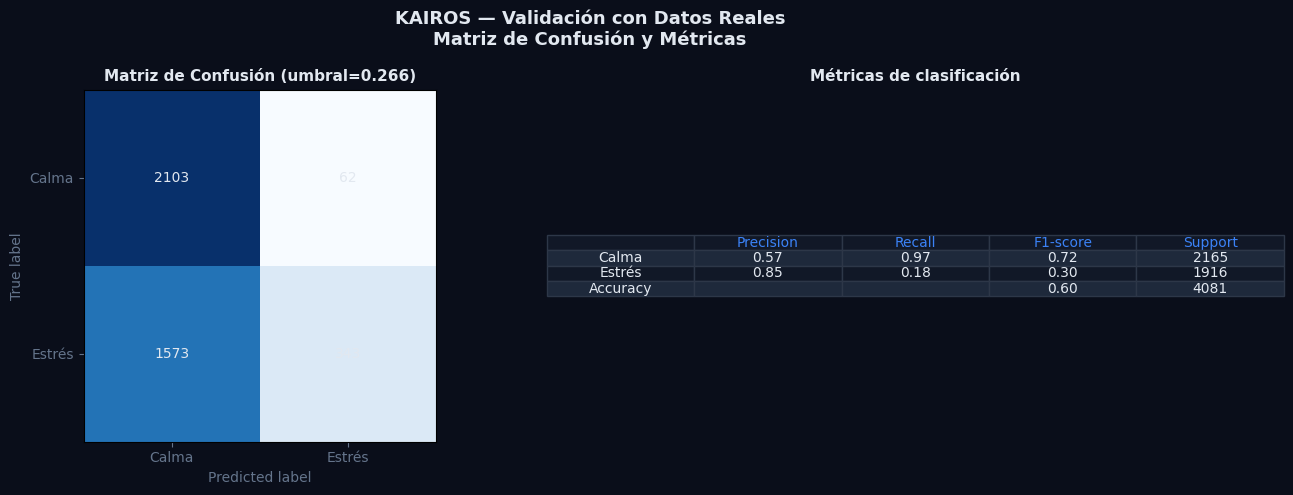

              precision    recall  f1-score   support

       Calma       0.57      0.97      0.72      2165
      Estrés       0.85      0.18      0.30      1916

    accuracy                           0.60      4081
   macro avg       0.71      0.58      0.51      4081
weighted avg       0.70      0.60      0.52      4081



In [385]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0A0E1A')
C = {'bg':'#111827', 'text':'#E2E8F0', 'sub':'#64748B'}

# ── Matriz de confusión ───────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor(C['bg'])
cm = confusion_matrix(y_true, df_filtrado['pred_label'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Calma', 'Estrés'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Matriz de Confusión (umbral=0.266)', 
              color=C['text'], fontsize=11, fontweight='bold')
for text in ax1.texts:
    text.set_color(C['text'])
ax1.tick_params(colors=C['sub'])
ax1.xaxis.label.set_color(C['sub'])
ax1.yaxis.label.set_color(C['sub'])

# ── Reporte de clasificación como tabla ───────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(C['bg'])
ax2.axis('off')

report = classification_report(y_true, df_filtrado['pred_label'],
                                target_names=['Calma', 'Estrés'],
                                output_dict=True)
tabla = [
    ['',          'Precision', 'Recall', 'F1-score', 'Support'],
    ['Calma',     f"{report['Calma']['precision']:.2f}",
                  f"{report['Calma']['recall']:.2f}",
                  f"{report['Calma']['f1-score']:.2f}",
                  f"{int(report['Calma']['support'])}"],
    ['Estrés',    f"{report['Estrés']['precision']:.2f}",
                  f"{report['Estrés']['recall']:.2f}",
                  f"{report['Estrés']['f1-score']:.2f}",
                  f"{int(report['Estrés']['support'])}"],
    ['Accuracy',  '', '', f"{report['accuracy']:.2f}", f"{len(y_true)}"],
]

table = ax2.table(cellText=tabla[1:], colLabels=tabla[0],
                  cellLoc='center', loc='center', colWidths=[0.22]*5)
table.auto_set_font_size(False)
table.set_fontsize(10)
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor(C['bg'] if row % 2 == 0 else '#1E293B')
    cell.set_text_props(color=C['text'] if row > 0 else '#3B82F6')
    cell.set_edgecolor('#2D3748')

ax2.set_title('Métricas de clasificación', 
              color=C['text'], fontsize=11, fontweight='bold')

fig.suptitle('KAIROS — Validación con Datos Reales\nMatriz de Confusión y Métricas',
             color=C['text'], fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/alma/bot/kairos_confusion_matrix.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(classification_report(y_true, df_filtrado['pred_label'], 
                             target_names=['Calma', 'Estrés']))

In [382]:
# Buscar umbral óptimo por índice de Youden
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, df_filtrado['prob_crisis'])
youden = tpr - fpr
umbral_optimo = thresholds[np.argmax(youden)]

print(f'Umbral óptimo (Youden): {umbral_optimo:.3f}')

# Reevaluar con umbral óptimo
df_filtrado['pred_optimo'] = (df_filtrado['prob_crisis'] >= umbral_optimo).astype(int)

print(classification_report(y_true, df_filtrado['pred_optimo'],
                             target_names=['Calma', 'Estrés']))

Umbral óptimo (Youden): 0.461
              precision    recall  f1-score   support

       Calma       0.57      0.96      0.72      2165
      Estrés       0.81      0.19      0.31      1916

    accuracy                           0.60      4081
   macro avg       0.69      0.58      0.51      4081
weighted avg       0.69      0.60      0.53      4081



In [383]:
# Validación por proporción de picos — la métrica correcta para KAIROS
print("=== VALIDACIÓN POR DETECCIÓN DE PICOS ===")
print("(métrica apropiada para detección de crisis agudas)\n")

for fecha in TODAS_FECHAS:
    subset = df_filtrado[df_filtrado['fecha'] == fecha]
    if len(subset) == 0:
        continue
    label = 'ESTRÉS' if fecha in list(FECHAS_ESTRES) else 'CALMA'
    picos = (subset['z_hr'] > 1.5).sum()
    p_max = subset['prob_crisis'].max()
    print(f'{fecha.date()} [{label}]: '
          f'{picos}/{len(subset)} ventanas activas '
          f'({picos/len(subset)*100:.1f}%) | '
          f'p(crisis) máx: {p_max:.3f}')

# Comparación agregada
estres_pct = df_filtrado[df_filtrado['label']==1].apply(
    lambda row: row['z_hr'] > 1.5, axis=1).mean() * 100
calma_pct = df_filtrado[df_filtrado['label']==0].apply(
    lambda row: row['z_hr'] > 1.5, axis=1).mean() * 100

print(f'\nPromedio ventanas activas — Estrés: {estres_pct:.1f}%')
print(f'Promedio ventanas activas — Calma:  {calma_pct:.1f}%')
print(f'Ratio: {estres_pct/calma_pct:.1f}x más picos en días de estrés')

=== VALIDACIÓN POR DETECCIÓN DE PICOS ===
(métrica apropiada para detección de crisis agudas)

2026-01-23 [ESTRÉS]: 274/512 ventanas activas (53.5%) | p(crisis) máx: 0.840
2026-02-09 [ESTRÉS]: 372/449 ventanas activas (82.9%) | p(crisis) máx: 0.933
2026-03-02 [ESTRÉS]: 296/473 ventanas activas (62.6%) | p(crisis) máx: 0.928
2026-06-09 [ESTRÉS]: 190/482 ventanas activas (39.4%) | p(crisis) máx: 0.889
2026-04-26 [CALMA]: 28/468 ventanas activas (6.0%) | p(crisis) máx: 0.812
2026-03-01 [CALMA]: 14/470 ventanas activas (3.0%) | p(crisis) máx: 0.750
2025-12-10 [CALMA]: 19/824 ventanas activas (2.3%) | p(crisis) máx: 0.630
2026-01-08 [CALMA]: 41/403 ventanas activas (10.2%) | p(crisis) máx: 0.904

Promedio ventanas activas — Estrés: 59.1%
Promedio ventanas activas — Calma:  4.7%
Ratio: 12.5x más picos en días de estrés


In [384]:
df_picos = df_filtrado[df_filtrado['z_hr'] > 1.5].copy()

print(f"Ventanas de pico: {len(df_picos):,}")
print(f"  Calma:  {(df_picos['label']==0).sum():,}")
print(f"  Estrés: {(df_picos['label']==1).sum():,}")

from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(df_picos['label'], df_picos['pred_label'],
                             target_names=['Calma', 'Estrés']))
print(f"AUC-ROC: {roc_auc_score(df_picos['label'], df_picos['prob_crisis']):.3f}")

Ventanas de pico: 1,234
  Calma:  102
  Estrés: 1,132
              precision    recall  f1-score   support

       Calma       0.08      0.73      0.15       102
      Estrés       0.92      0.29      0.44      1132

    accuracy                           0.32      1234
   macro avg       0.50      0.51      0.30      1234
weighted avg       0.85      0.32      0.42      1234

AUC-ROC: 0.518


In [359]:
# Agrupar por fecha y hora para ver la densidad de alertas
df_filtrado['hora'] = df_filtrado['window'].dt.hour
reporte_alertas = df_filtrado.groupby(['fecha', 'label']).agg(
    total_ventanas=('pred_label', 'count'),
    alertas_rf=('pred_label', 'sum'),
    picos_z=('z_hr', lambda x: (x > 1.5).sum())
).reset_index()

print(reporte_alertas)

       fecha  label  total_ventanas  alertas_rf  picos_z
0 2025-12-10      0             824          15       14
1 2026-01-08      0             403          24       32
2 2026-01-12      0             346          28       59
3 2026-01-23      1             512          60      232
4 2026-02-09      1             449         134      360
5 2026-03-01      0             470          11        9
6 2026-03-02      1             473          71      270
7 2026-06-09      1             482          40      156


In [372]:
import zipfile

zip_path = '/home/alma/bot/takeout-20260612T142925Z-3-001.zip'

# Verificar cuáles de los mejores candidatos tienen micro_motion
candidatos_con_motion = []
fechas_candidatas = [
    '2025-12-06', '2025-12-09', '2025-12-13', '2025-12-15',
    '2025-12-27', '2025-12-30', '2025-12-31',
    '2026-02-01', '2026-02-05', '2026-02-12', '2026-02-15',
    '2026-02-21', '2026-02-22', '2026-02-28',
    '2026-03-04', '2026-03-05', '2026-03-07', '2026-03-10',
    '2026-04-03', '2026-04-24', '2026-04-26', '2026-04-30',
]

with zipfile.ZipFile(zip_path) as zf:
    nombres = zf.namelist()
    for fecha in fechas_candidatas:
        path = f'Takeout/Google Health/Physical Activity_GoogleData/micro_motion_{fecha}.csv'
        tiene = path in nombres
        print(f'{fecha}: {"✅" if tiene else "❌"}')

2025-12-06: ❌
2025-12-09: ❌
2025-12-13: ✅
2025-12-15: ✅
2025-12-27: ✅
2025-12-30: ✅
2025-12-31: ✅
2026-02-01: ✅
2026-02-05: ✅
2026-02-12: ✅
2026-02-15: ✅
2026-02-21: ✅
2026-02-22: ✅
2026-02-28: ✅
2026-03-04: ✅
2026-03-05: ✅
2026-03-07: ✅
2026-03-10: ✅
2026-04-03: ✅
2026-04-24: ✅
2026-04-26: ✅
2026-04-30: ✅


In [374]:
fechas_probar = ['2025-12-13', '2025-12-15', '2025-12-27',
                 '2025-12-30', '2025-12-31', '2026-02-01',
                 '2026-02-05', '2026-02-12', '2026-02-15',
                 '2026-02-21', '2026-02-22', '2026-02-28',
                 '2026-03-04', '2026-03-05', '2026-04-03',
                 '2026-04-26', '2026-04-30']

HR_JSON_DIR = '/home/alma/bot/Takeout/Google Health/Global Export Data/'

for fecha_str in fechas_probar:
    path = f'{HR_JSON_DIR}heart_rate-{fecha_str}.json'
    try:
        with open(path) as fp:
            data = json.load(fp)
        bpms = [float(s['value']['bpm']) for s in data
                if int(s['value']['confidence']) >= 2
                and dtime(8,0) <= datetime.strptime(
                    s['dateTime'],'%m/%d/%y %H:%M:%S').time() <= dtime(22,0)
                and float(s['value']['bpm']) <= 120]
        if bpms:
            print(f'{fecha_str}: HR media {np.mean(bpms):.1f} BPM')
    except:
        print(f'{fecha_str}: sin datos') 

2025-12-13: HR media 80.2 BPM
2025-12-15: HR media 79.7 BPM
2025-12-27: HR media 81.1 BPM
2025-12-30: HR media 80.5 BPM
2025-12-31: HR media 80.7 BPM
2026-02-01: HR media 78.0 BPM
2026-02-05: HR media 77.7 BPM
2026-02-12: HR media 77.2 BPM
2026-02-15: HR media 80.0 BPM
2026-02-21: HR media 76.7 BPM
2026-02-22: HR media 80.1 BPM
2026-02-28: HR media 77.9 BPM
2026-03-04: HR media 76.4 BPM
2026-03-05: HR media 78.2 BPM
2026-04-03: HR media 78.1 BPM
2026-04-26: HR media 76.1 BPM
2026-04-30: HR media 77.3 BPM
